In [30]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian_action2D import run_to_end, DistortedLens, Biprism, make_gaussian_plane_wave_square_aperture
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.utils import energy2wavelength, reconstruct_complex
from temgym_core.aberrations import KrivanekCoeffs

from skimage.restoration import unwrap_phase

In [31]:
window_width = 1e-6  # metres
Nx = Ny = 1024
pixel_size = window_width / Nx
voltage = 100e3  # volts
wavelength = energy2wavelength(voltage)
k = 2 * np.pi / wavelength
input_grid = Detector(
    z=0.0,
    pixel_size=(pixel_size, pixel_size),
    shape=(Ny, Nx),
)

input_extent = input_grid.extent

In [47]:
rays_in = make_gaussian_plane_wave_square_aperture(voltage=100e3, 
                                                   aperture_length=window_width*0.9, 
                                                   num_rays=200_000,
                                                   waist=2e-9)

In [48]:
run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)), static_argnums=(1,)
)
rays_out = run_to_end_vmapped(rays_in, ())
field = evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_grid).block_until_ready()

/tmp/ipykernel_4087192/1829251537.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)


Text(0, 0.5, 'y (µm)')

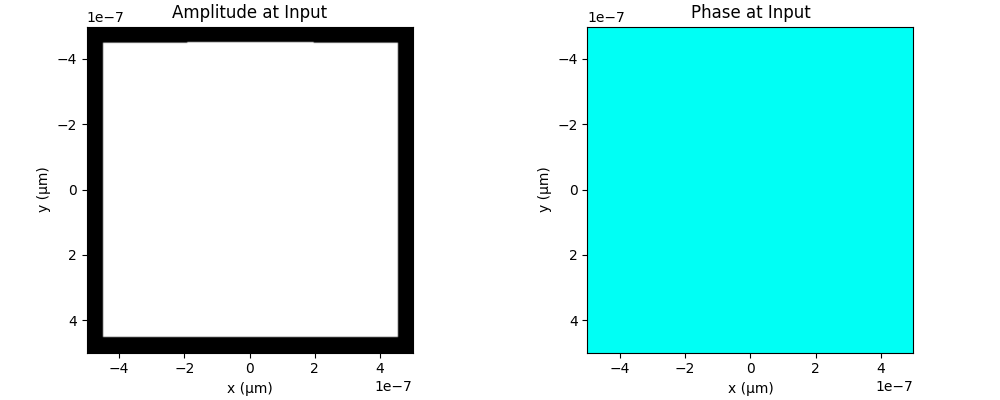

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
im0 = axs[0].imshow(
    np.abs(field),
    extent=input_extent,
    cmap='gray',
)
axs[0].set_title('Amplitude at Input')
axs[0].set_xlabel('x (\u00b5m)')
axs[0].set_ylabel('y (\u00b5m)')

im1 = axs[1].imshow(
    np.angle(field),
    extent=input_extent,
    cmap='hsv',
    vmin=-np.pi,
    vmax=np.pi,
)
axs[1].set_title('Phase at Input')
axs[1].set_xlabel('x (\u00b5m)')
axs[1].set_ylabel('y (\u00b5m)')

In [50]:
M1, f1 = -80, 1e-2
defocus = 0.0
z1, z2 = calculate_z1_and_z2_from_M_and_f(M=M1, f=f1)
z1, z2 = map(abs, (z1, z2))

aberrated_lens = DistortedLens(z=z1, z1=z1, focal_length=f1, IsoDist=1e11)
biprism = Biprism(z=(z1 + z2) / 2, strength=0.00005, width=1e-11)
detector = Detector(
    z=z1 + z2 + defocus,
    pixel_size=(pixel_size * abs(M1), pixel_size * abs(M1)),
    shape=(Ny, Nx),
)
extent = detector.extent
extent_um = tuple(float(val) * 1e6 for val in extent)

In [51]:
rays_out_no_biprism = run_to_end_vmapped(rays_in, (aberrated_lens, detector))
field_no_biprism = evaluate_gaussians_gpu_kernel_wrapper(rays_out_no_biprism, detector).block_until_ready()
field_no_biprism_intensity = np.abs(field_no_biprism) ** 2

In [52]:
rays_out_with_biprism = run_to_end_vmapped(rays_in, (aberrated_lens, biprism, detector))
field_with_biprism = evaluate_gaussians_gpu_kernel_wrapper(rays_out_with_biprism, detector).block_until_ready()
field_with_biprism_intensity = np.abs(field_with_biprism) ** 2

Text(0.5, 1.0, 'With Biprism')

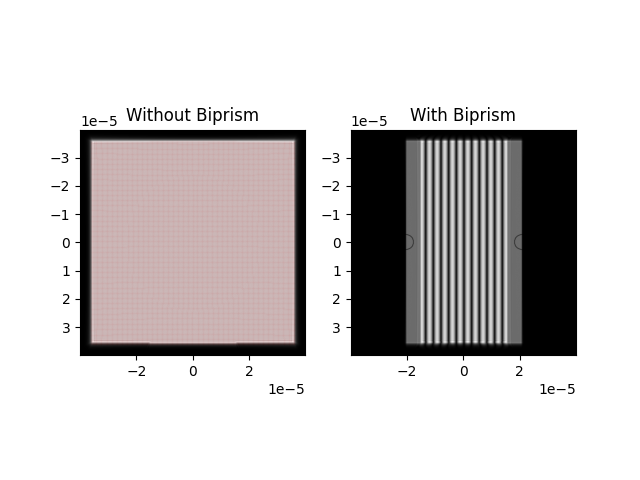

In [53]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(np.abs(field_no_biprism), extent=extent, cmap='gray')
axs[0].plot(rays_out_no_biprism.x, rays_out_no_biprism.y, 'r.', markersize=0.5, alpha=0.01)
axs[0].set_title('Without Biprism')
axs[1].imshow(np.abs(field_with_biprism), extent=extent, cmap='gray')
# axs[1].plot(rays_out_with_biprism.x, rays_out_with_biprism.y, 'w.', markersize=0.5, alpha=0.1)
axs[1].set_title('With Biprism')

In [54]:
ref = reconstruct_complex(
    field_with_biprism_intensity,
    exclude_radius=5,
    sigma_pixels=25,
    sideband_center=None,
)

phase = ref['phase_wrapped']

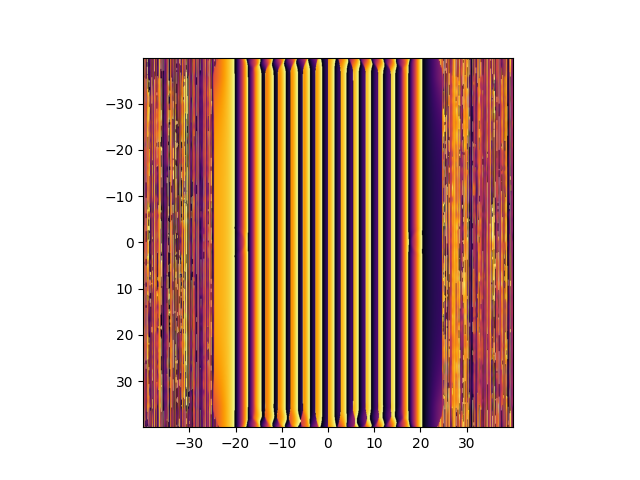

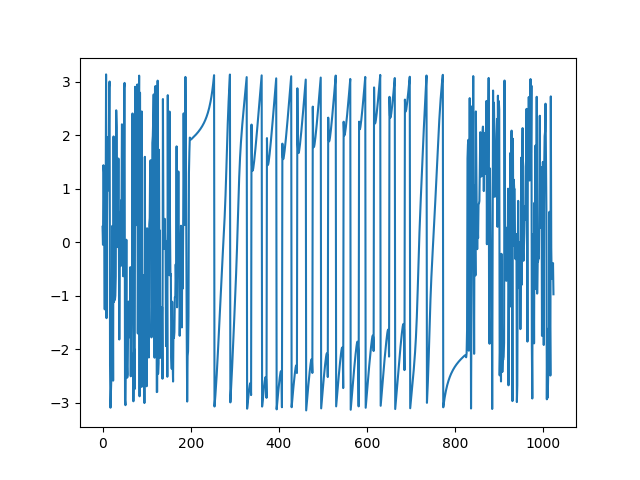

In [55]:
plt.figure()
plt.imshow(phase, extent=extent_um, cmap='inferno')

plt.figure()
plt.plot(phase[Nx//2, :])